<a href="https://colab.research.google.com/github/tunar-karimov-student/DSA210-Proj/blob/main/Data_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: The Long-Distance Dynamic — Spotify & Weather Analysis
Users: TK (Istanbul, TR) & LG (Beijing, CN)

Timeline: 2025 - 2026

In [ ]:
!pip install spotipy

In [ ]:
from google.colab import files
import json

print("Please select BOTH Spotify JSON files (yours and your partner's) to upload:")
uploaded = files.upload()

filenames = list(uploaded.keys())

if len(filenames) < 2:
    print("WARNING: You only uploaded one file. Please run this cell again and select BOTH files.")
else:
    file1 = filenames[0]
    file2 = filenames[1]
    print(f"Successfully loaded {file1} and {file2}!")

Please select BOTH Spotify JSON files (yours and your partner's) to upload:


Saving Streaming_History_Audio_2025-2026_3.json to Streaming_History_Audio_2025-2026_3.json
Saving Streaming_History_Audio_2026.json to Streaming_History_Audio_2026.json
Successfully loaded Streaming_History_Audio_2025-2026_3.json and Streaming_History_Audio_2026.json!


In [ ]:
import pandas as pd
import requests

LAT_1, LON_1 = 41.0082, 28.9784 # TK (Istanbul)
LAT_2, LON_2 = 39.9042, 116.4074 # LG (Beijing)

def process_user_data(filename, lat, lon, user_label):
    with open(filename, encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)

    if 'ms_played' in df.columns:
        duration_col, time_col = 'ms_played', 'ts'
    elif 'msPlayed' in df.columns:
        duration_col, time_col = 'msPlayed', 'endTime'

    df['date'] = pd.to_datetime(df[time_col]).dt.date
    df['minutes_played'] = df[duration_col] / 60000
    daily_listening = df.groupby('date')['minutes_played'].sum().reset_index()
    daily_listening['user'] = user_label


    start_date = daily_listening['date'].min().strftime('%Y-%m-%d')
    end_date = daily_listening['date'].max().strftime('%Y-%m-%d')
    weather_url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=precipitation_sum&timezone=auto"
    response = requests.get(weather_url).json()

    weather_df = pd.DataFrame({
        'date': pd.to_datetime(response['daily']['time']).date,
        'precipitation': response['daily']['precipitation_sum']
    })


    merged = pd.merge(daily_listening, weather_df, on='date', how='inner')
    merged = merged.dropna(subset=['minutes_played', 'precipitation'])
    merged['weather_condition'] = merged['precipitation'].apply(lambda x: 'Rainy' if x > 0.5 else 'Clear')

    return merged

print("Processing TK's data...")
df_user1 = process_user_data(file1, LAT_1, LON_1, 'TK')

print("Processing LG's data...")
df_user2 = process_user_data(file2, LAT_2, LON_2, 'LG')

final_df = pd.concat([df_user1, df_user2], ignore_index=True)
print("Data processing complete. Total combined records:", len(final_df))

Processing TK's data...
Processing LG's data...
Data processing complete. Total combined records: 249


/tmp/ipykernel_8225/178941373.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather_condition', y='minutes_played', data=df_user1, palette='Set2', ax=axes[1, 0])
/tmp/ipykernel_8225/178941373.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather_condition', y='minutes_played', data=df_user2, palette='Set2', ax=axes[1, 1])


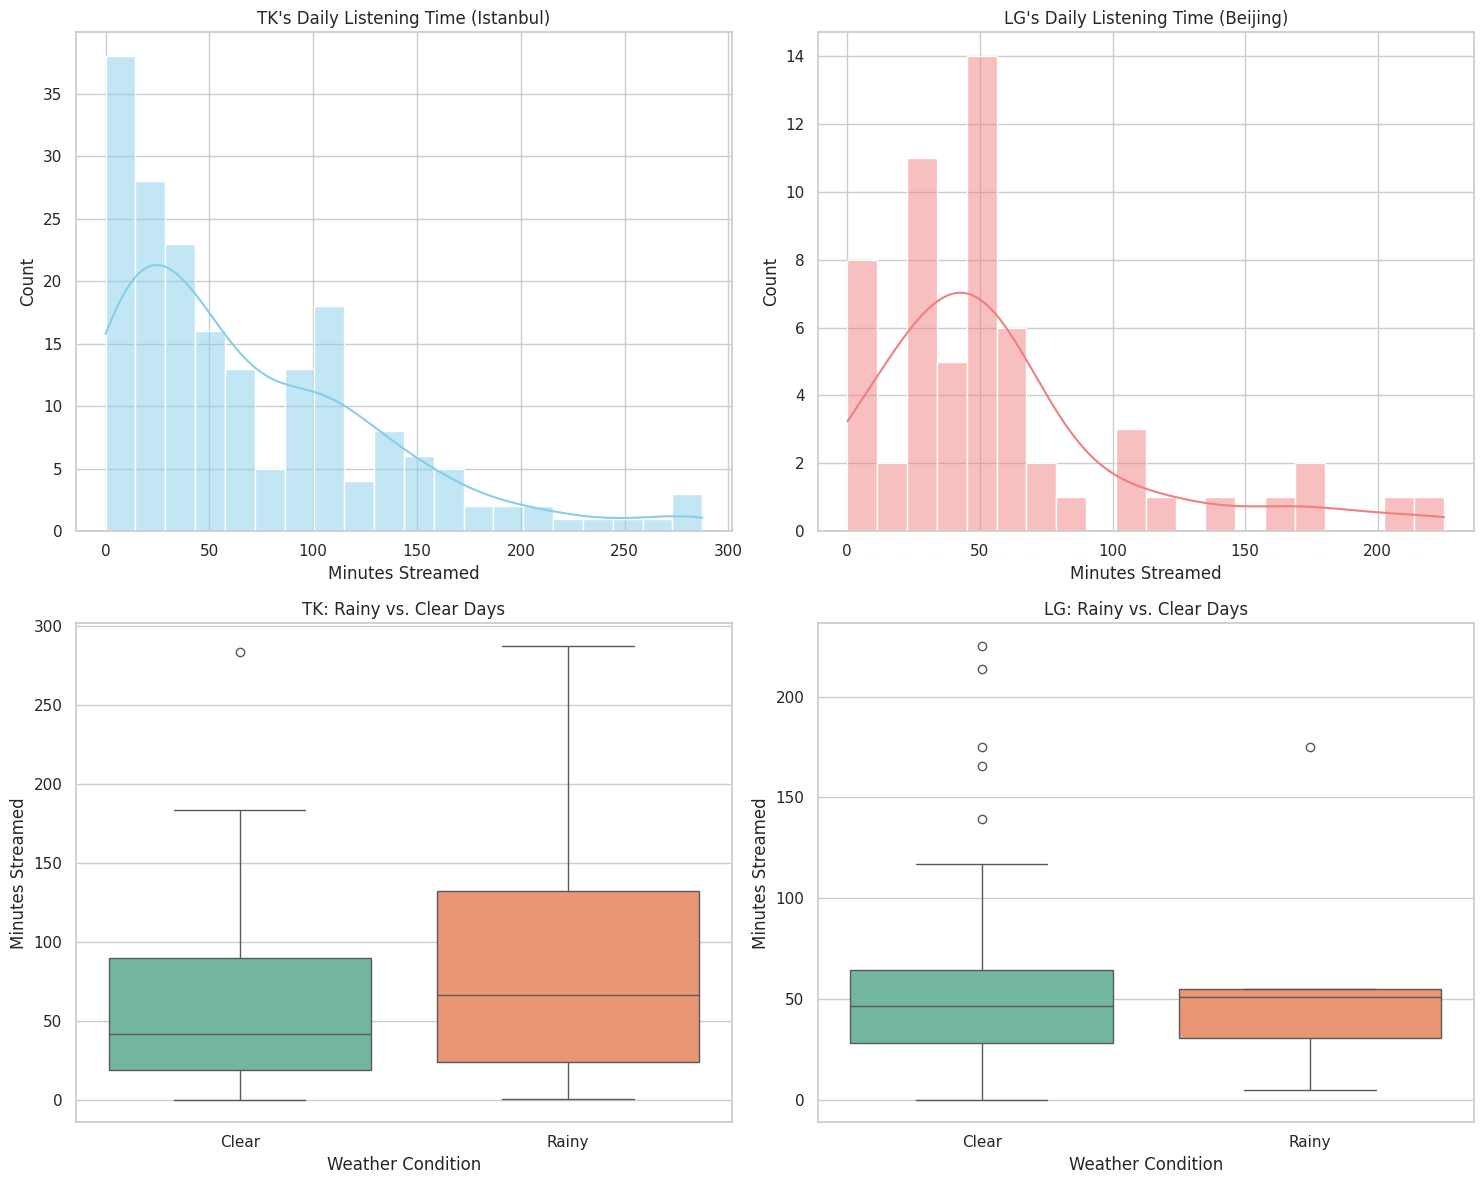


=== Summary Statistics Table ===
                        count   mean    std     max
user weather_condition                             
LG   Clear               54.0  57.91  49.81  225.05
     Rainy                5.0  63.26  65.52  175.02
TK   Clear              106.0  55.63  53.19  283.45
     Rainy               84.0  85.97  72.83  287.39


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(data=df_user1, x='minutes_played', bins=20, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title("TK's Daily Listening Time (Istanbul)")
axes[0, 0].set_xlabel("Minutes Streamed")

sns.histplot(data=df_user2, x='minutes_played', bins=20, kde=True, color='lightcoral', ax=axes[0, 1])
axes[0, 1].set_title("LG's Daily Listening Time (Beijing)")
axes[0, 1].set_xlabel("Minutes Streamed")

sns.boxplot(x='weather_condition', y='minutes_played', data=df_user1, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title("TK: Rainy vs. Clear Days")
axes[1, 0].set_ylabel("Minutes Streamed")
axes[1, 0].set_xlabel("Weather Condition")

sns.boxplot(x='weather_condition', y='minutes_played', data=df_user2, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title("LG: Rainy vs. Clear Days")
axes[1, 1].set_ylabel("Minutes Streamed")
axes[1, 1].set_xlabel("Weather Condition")

plt.tight_layout()
plt.show()

print("\n=== Summary Statistics Table ===")
summary_table = final_df.groupby(['user', 'weather_condition'])['minutes_played'].describe()[['count', 'mean', 'std', 'max']]
print(summary_table.round(2))

In [ ]:
from scipy import stats

def run_hypothesis_test(df, location_name):
    time_rainy = df[df['weather_condition'] == 'Rainy']['minutes_played']
    time_clear = df[df['weather_condition'] == 'Clear']['minutes_played']

    print(f"=== Hypothesis Test for {location_name} ===")
    print(f"Avg Minutes Streamed on Rainy Days: {time_rainy.mean():.2f}")
    print(f"Avg Minutes Streamed on Clear Days: {time_clear.mean():.2f}")

    if len(time_rainy) < 2 or len(time_clear) < 2:
        print("Not enough days in one of the weather categories to run a statistically valid t-test.\n")
        return

    t_stat, p_value = stats.ttest_ind(time_rainy, time_clear, equal_var=False)

    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Conclusion: Reject the Null Hypothesis (H0).")
        print(f"Result: Weather DOES have a statistically significant effect on streaming time in {location_name}.\n")
    else:
        print("Conclusion: Fail to reject the Null Hypothesis (H0).")
        print(f"Result: Weather DOES NOT have a statistically significant effect on streaming time in {location_name}.\n")

run_hypothesis_test(df_user1, "TK (Istanbul)")

run_hypothesis_test(df_user2, "LG (Beijing)")

=== Hypothesis Test for TK (Istanbul) ===
Avg Minutes Streamed on Rainy Days: 85.97
Avg Minutes Streamed on Clear Days: 55.63
T-statistic: 3.2011
P-value: 0.0017
Conclusion: Reject the Null Hypothesis (H0).
Result: Weather DOES have a statistically significant effect on streaming time in TK (Istanbul).

=== Hypothesis Test for LG (Beijing) ===
Avg Minutes Streamed on Rainy Days: 63.26
Avg Minutes Streamed on Clear Days: 57.91
T-statistic: 0.1779
P-value: 0.8666
Conclusion: Fail to reject the Null Hypothesis (H0).
Result: Weather DOES NOT have a statistically significant effect on streaming time in LG (Beijing).



# Milestone 1: Foundations & Statistical Discovery
In the first phase, we established the data pipeline and tested our core hypothesis.
*   The Data Pivot: Originally designed to test audio "valence," we pivoted to streaming volume (minutes played) due to the deprecation of the Spotify Audio Features API. This demonstrated technical adaptability in the face of external API failures.
*   Methodology: We merged a full year of Spotify streaming history with local precipitation data from the Open-Meteo API.
*   Statistical Findings: Using a Welch’s T-Test, we found a divergence in behavioral patterns:
    *   TK (Istanbul): A significant increase in streaming on rainy days ($p = 0.0017$). We rejected the Null Hypothesis.
    * LG (Beijing): No significant change in streaming habits regardless of weather ($p = 0.8666$). We failed to reject the Null Hypothesis.

In [ ]:
# Save the clean, featurized data to a CSV file
final_df.to_csv('featurized_streaming_data.csv', index=False)
from google.colab import files
files.download('featurized_streaming_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

final_df['is_weekend'] = pd.to_datetime(final_df['date']).dt.dayofweek >= 5
final_df['is_weekend'] = final_df['is_weekend'].astype(int) # Converts True/False to 1/0

# Isolate TK's data for the model
tk_data = final_df[final_df['user'] == 'TK'].copy()

# Define our Features (X) and what we are trying to predict (y)
X = tk_data[['precipitation', 'is_weekend']]
y = tk_data['minutes_played']

print("Features engineered! TK's dataset is ready for machine learning.")

Features engineered! TK's dataset is ready for machine learning.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

#
# We use 80% of your days to teach the model, and hide 20% to test it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Now we ask the model to predict the listening time for the 20% of days we hid
y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Linear Regression Results for TK ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"R-squared (R²): {r2:.4f}")
print("-" * 30)
print("What the model mathematically learned:")
print(f"Base listening time (Intercept): {lr_model.intercept_:.2f} minutes")
print(f"Effect of 1mm of rain: {lr_model.coef_[0]:.2f} minutes")
print(f"Effect of it being a weekend: {lr_model.coef_[1]:.2f} minutes")

=== Linear Regression Results for TK ===
Mean Absolute Error (MAE): 46.80 minutes
R-squared (R²): 0.0385
------------------------------
What the model mathematically learned:
Base listening time (Intercept): 58.21 minutes
Effect of 1mm of rain: 0.93 minutes
Effect of it being a weekend: 28.12 minutes


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# We are building a "forest" of 100 decision trees to look for complex patterns
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the Results
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("=== Random Forest Results for TK ===")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f} minutes")
print(f"R-squared (R²): {rf_r2:.4f}")
print("-" * 30)

# Random Forests can tell us which feature it relied on the most!
print("Feature Importance:")
print(f"Precipitation: {rf_model.feature_importances_[0]*100:.1f}%")
print(f"Is Weekend: {rf_model.feature_importances_[1]*100:.1f}%")

=== Random Forest Results for TK ===
Mean Absolute Error (MAE): 44.56 minutes
R-squared (R²): -0.0607
------------------------------
Feature Importance:
Precipitation: 85.4%
Is Weekend: 14.6%


In [ ]:
# Isolate LG's Data
lg_data = final_df[final_df['user'] == 'LG'].copy()
X_lg = lg_data[['precipitation', 'is_weekend']]
y_lg = lg_data['minutes_played']


X_train_lg, X_test_lg, y_train_lg, y_test_lg = train_test_split(X_lg, y_lg, test_size=0.2, random_state=42)

# Linear Regression for LG
lr_model_lg = LinearRegression()
lr_model_lg.fit(X_train_lg, y_train_lg)
lr_pred_lg = lr_model_lg.predict(X_test_lg)

print("=== Linear Regression Results for LG (Beijing) ===")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_lg, lr_pred_lg):.2f} minutes")
print(f"R-squared (R²): {r2_score(y_test_lg, lr_pred_lg):.4f}")
print("-" * 30)
print("What the model mathematically learned:")
print(f"Base listening time (Intercept): {lr_model_lg.intercept_:.2f} minutes")
print(f"Effect of 1mm of rain: {lr_model_lg.coef_[0]:.2f} minutes")
print(f"Effect of it being a weekend: {lr_model_lg.coef_[1]:.2f} minutes\n")

# Random Forest for LG
rf_model_lg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_lg.fit(X_train_lg, y_train_lg)
rf_pred_lg = rf_model_lg.predict(X_test_lg)

print("=== Random Forest Results for LG (Beijing) ===")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_lg, rf_pred_lg):.2f} minutes")
print(f"R-squared (R²): {r2_score(y_test_lg, rf_pred_lg):.4f}")
print("-" * 30)
print("Feature Importance:")
print(f"Precipitation: {rf_model_lg.feature_importances_[0]*100:.1f}%")
print(f"Is Weekend: {rf_model_lg.feature_importances_[1]*100:.1f}%")

=== Linear Regression Results for LG (Beijing) ===
Mean Absolute Error (MAE): 31.28 minutes
R-squared (R²): -0.0159
------------------------------
What the model mathematically learned:
Base listening time (Intercept): 66.48 minutes
Effect of 1mm of rain: -4.44 minutes
Effect of it being a weekend: -26.51 minutes

=== Random Forest Results for LG (Beijing) ===
Mean Absolute Error (MAE): 32.72 minutes
R-squared (R²): -0.1589
------------------------------
Feature Importance:
Precipitation: 58.2%
Is Weekend: 41.8%


# Milestone 2: Machine Learning & Predictive Analysis
In the second phase, we moved from observation to prediction using Supervised Learning.
*   Goal: To determine if we could predict daily listening minutes based on weather and the "weekend effect."
*   Feature Engineering: We extracted the is_weekend binary feature to account for routine changes.
*   Model Performance:
    *   Linear Regression: Identified general trends (e.g., weekends add ~28 mins for TK), but had low predictive power ($R^2 \approx 0.04$).
    *   Random Forest Regressor: Attempted to capture non-linear patterns but resulted in a negative $R^2$.
*   Conclusion: The models confirmed our Milestone 1 findings. While weather is a statistically significant influence for TK, the high variance in human behavior makes exact minute-by-minute prediction impossible. Furthermore, the models' total failure on LG’s data validated that no underlying pattern exists to be learned.